In [139]:
import os
import glob
from enum import Enum

import torch
from torchvision.ops import box_iou

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches


In [2]:
class Channel(Enum):
    Player_1_Worker = 0
    Player_1_Ground = 1
    Player_1_Air = 2
    Player_1_Building = 3
    
    Player_2_Worker = 4
    Player_2_Ground = 5
    Player_2_Air = 6
    Player_2_Building = 7
    
    Resource = 8
    Vision = 9
    Terrain = 10

In [111]:
STORAGE_DIR = "/mnt/ex_ssd/starcraft-vision"

DATA_DIR = os.path.join(STORAGE_DIR, "data")
GROUND_TRUTH_DIR = os.path.join(DATA_DIR, "label", "dst")
PREDICTIONS_DIR = os.path.join(STORAGE_DIR, "predictions")


In [112]:
REPLAYS = ['36.rep', '212.rep', '438.rep', '522.rep', '1660.rep', '6254.rep']

In [113]:
INFERENCE_MODEL = "vanilla/all_correct_win4_b16_20250812_062928"

In [ ]:
ground_truth_json_path = [
    f for name in REPLAYS
    for f in glob.glob(os.path.join(GROUND_TRUTH_DIR, name, '*.json'))
]

In [68]:
def read_json_files(directory, label_method='all_correct', replays=None):
    data = []

    if replays:
        targets = [os.path.join(rep, f"{label_method}.json") for rep in replays]
    else:
        targets = os.listdir(directory)

    for filename in targets:
        if filename.endswith(".json"):
            filepath = os.path.join(directory, filename)
            if os.path.isfile(filepath):
                with open(filepath, "r", encoding="utf-8") as f:
                    data.append(json.load(f))

    return data

In [ ]:
ground_truth_data = read_json_files(GROUND_TRUTH_DIR, label_method='all_correct', replays=REPLAYS)

In [73]:
prediction_data = read_json_files(os.path.join(PREDICTIONS_DIR, INFERENCE_MODEL), label_method='all_correct')

In [83]:
def get_annotations(data, replay_suffix=".rep"):
    frames = []

    for item in (data or []):
        anns = item.get("annotations", [])
        if not anns:
            continue

        df = pd.DataFrame(anns)

        desc = (item.get("info") or {}).get("description", "") or ""
        replay_id = None
        if isinstance(desc, str) and desc.strip():
            replay_id = desc.strip().split()[-1]

        if replay_id is None:
            replay_id = "unknown"

        if replay_suffix and not str(replay_id).endswith(replay_suffix):
            replay_id = f"{replay_id}{replay_suffix}"

        df["replay"] = replay_id
        frames.append(df)

    base_cols = ["replay", "id", "image_id", "category_id", "bbox", "area", "segmentation", "iscrowd"]
    if not frames:
        return pd.DataFrame(columns=base_cols + ["score"])

    has_score = any("score" in f.columns for f in frames)

    wanted_cols = base_cols + (["score"] if has_score else [])
    for i, f in enumerate(frames):
        for col in wanted_cols:
            if col not in f.columns:
                frames[i][col] = pd.NA

    annotations = pd.concat(frames, ignore_index=True)

    return annotations[wanted_cols]

In [86]:
annotation_ground_truth = get_annotations(ground_truth_data)
annotation_prediction = get_annotations(prediction_data)

In [ ]:
def plot_occurrence_counts(ax, dataframe, xlabel, ylabel, title):
    counts = dataframe.groupby(['replay', 'image_id']).size()
    
    ax.hist(
        counts,
        bins=range(1, counts.max() + 2),
        edgecolor='black',
        align='left'
    )
    
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(0, max(counts.max(), counts.max()) + 1, 5))   

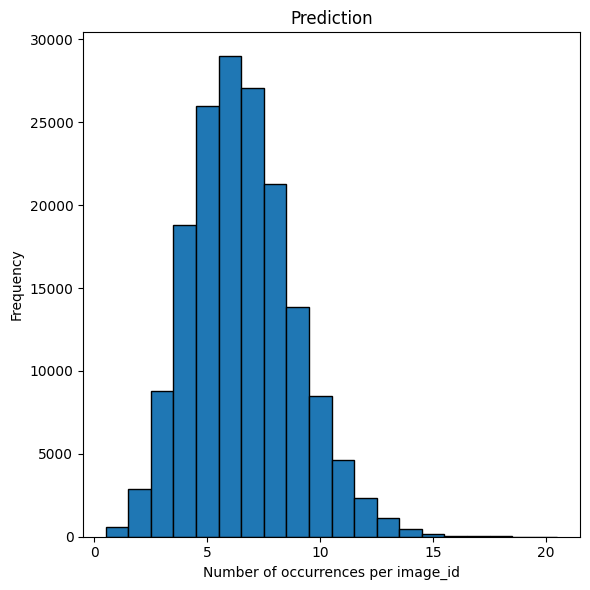

In [108]:
# fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=300, sharey=True)

# plot_occurrence_counts(axes[0], annotation_ground_truth, ylabel='Occurrences', title='Ground Truth Occurrences')
# plot_occurrence_counts(axes[1], annotation_prediction, ylabel='Occurrences', title='Prediction Occurrences')

# plt.tight_layout()
# plt.show()

fig, ax = plt.subplots(1, 1, figsize=(6, 6), dpi=100, sharey=True)

plot_occurrence_counts(ax, annotation_prediction, ylabel='Frequency', xlabel='Number of occurrences per image_id', title='Prediction')

plt.tight_layout()
plt.show()

In [109]:
def plot_prediction_score(ax, dataframe, xlabel, ylabel, title):
    
    ax.hist(
        dataframe['score'],
        bins=20,
        edgecolor='black',
        align='left'
    )
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)


In [125]:
def dataframe_topk_score(dataframe, K):
    topk_df = (
      dataframe.sort_values('score', ascending=False)
        .groupby(['replay', 'image_id'], group_keys=False)
        .head(K)
    )
    return topk_df.sort_values(['replay', 'image_id'])

In [126]:
top1_annotation_prediction = dataframe_topk_score(annotation_prediction, 1)
top3_annotation_prediction = dataframe_topk_score(annotation_prediction, 3)
top5_annotation_prediction = dataframe_topk_score(annotation_prediction, 5)

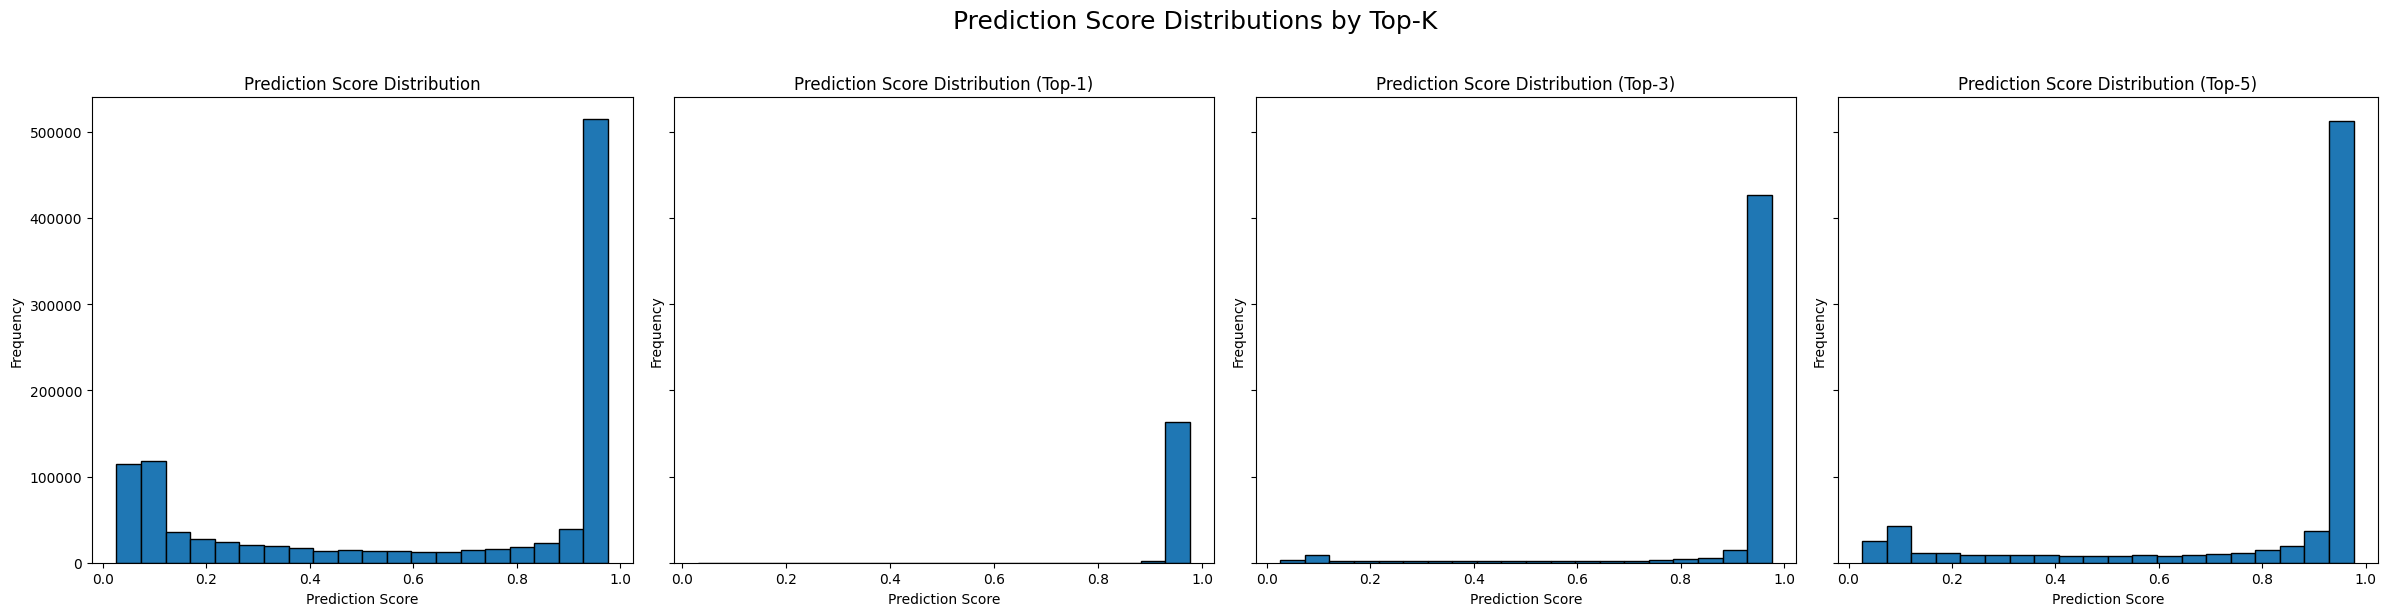

In [129]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6), dpi=100, sharey=True)

plot_prediction_score(axes[0], annotation_prediction, xlabel='Prediction Score', ylabel='Frequency', title='Prediction Score Distribution')
plot_prediction_score(axes[1], top1_annotation_prediction, xlabel='Prediction Score', ylabel='Frequency', title='Prediction Score Distribution (Top-1)')
plot_prediction_score(axes[2], top3_annotation_prediction, xlabel='Prediction Score', ylabel='Frequency', title='Prediction Score Distribution (Top-3)')
plot_prediction_score(axes[3], top5_annotation_prediction, xlabel='Prediction Score', ylabel='Frequency', title='Prediction Score Distribution (Top-5)')

fig.suptitle("Prediction Score Distributions by Top-K", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [140]:
def compute_iou_box(box1, box2):
    # box: [x, y, w, h] → convert to (x1, y1, x2, y2)
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    xi1 = max(x1, x2)
    yi1 = max(y1, y2)
    xi2 = min(x1 + w1, x2 + w2)
    yi2 = min(y1 + h1, y2 + h2)

    inter_area = max(xi2 - xi1, 0) * max(yi2 - yi1, 0)
    union_area = w1 * h1 + w2 * h2 - inter_area

    return inter_area / union_area if union_area > 0 else 0

In [141]:
def evaluate_iou(gt_df, pred_df, iou_threshold=0.5):
    results = []
    keys_gt = set(zip(gt_df['replay'], gt_df['image_id']))
    keys_pred = set(zip(pred_df['replay'], pred_df['image_id']))
    shared_keys = sorted(keys_gt.intersection(keys_pred))  # 공통된 (replay, id)

    for replay, frame_id in shared_keys:
        gt_boxes = gt_df[(gt_df['replay'] == replay) & (gt_df['image_id'] == frame_id)]
        pred_boxes = pred_df[(pred_df['replay'] == replay) & (pred_df['image_id'] == frame_id)]

        matched_gt = set()
        tp = 0
        fp = 0
        ious = []

        for _, pred_row in pred_boxes.iterrows():
            best_iou = 0
            best_gt_idx = None
            for _, gt_row in gt_boxes.iterrows():
                if gt_row['image_id'] in matched_gt:
                    continue
                iou = compute_iou_box(pred_row['bbox'], gt_row['bbox'])
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = gt_row['image_id']
            if best_iou >= iou_threshold:
                tp += 1
                matched_gt.add(best_gt_idx)
                ious.append(best_iou)
            else:
                fp += 1

        fn = len(gt_boxes) - len(matched_gt)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0

        results.append({
            'replay': replay,
            'image_id': frame_id,
            'precision': precision,
            'recall': recall,
            'mean_iou': np.mean(ious) if ious else 0,
            'tp': tp,
            'fp': fp,
            'fn': fn
        })

    return pd.DataFrame(results)

In [142]:
def evaluate_single_iou_pre_split(args):
    (replay, image_id), gt_bboxes, pred_bboxes, iou_threshold = args

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    gt_boxes = torch.tensor(gt_bboxes, dtype=torch.float, device=device)
    pred_boxes = torch.tensor(pred_bboxes, dtype=torch.float, device=device)

    matched_gt = set()
    tp, fp, fn = 0, 0, 0
    ious = []

    if len(gt_boxes) == 0:
        tp, fp = 0, len(pred_boxes)
    elif len(pred_boxes) == 0:
        fn = len(gt_boxes)
    else:
        iou_matrix = box_iou(pred_boxes, gt_boxes)
        for pred_idx in range(iou_matrix.size(0)):
            ious_row = iou_matrix[pred_idx]
            best_iou, best_gt_idx = torch.max(ious_row, dim=0)
            if best_iou >= iou_threshold and best_gt_idx.item() not in matched_gt:
                tp += 1
                ious.append(best_iou.item())
                matched_gt.add(best_gt_idx.item())
            else:
                fp += 1
        fn = len(gt_boxes) - len(matched_gt)

    precision = tp / (tp + fp) if tp + fp > 0 else 0
    recall = tp / (tp + fn) if tp + fn > 0 else 0

    return {
        'replay': replay,
        'image_id': image_id,
        'precision': precision,
        'recall': recall,
        'mean_iou': np.mean(ious) if ious else 0,
        'tp': tp,
        'fp': fp,
        'fn': fn
    }


In [143]:
from collections import defaultdict

def make_frame_dict(df):
    frame_dict = defaultdict(list)
    for _, row in df.iterrows():
        key = (row['replay'], row['image_id'])
        frame_dict[key].append(row['bbox'])
    return {k: np.array(v) for k, v in frame_dict.items()}

In [144]:
from multiprocessing import Pool

def evaluate_iou_pre_split_parallel(gt_df, pred_df, iou_threshold=0.5, num_workers=None):
    if num_workers is None:
        from multiprocessing import cpu_count
        num_workers = cpu_count()

    gt_dict = make_frame_dict(gt_df)
    pred_dict = make_frame_dict(pred_df)
    shared_keys = sorted(set(gt_dict) & set(pred_dict))

    args_list = [
        ((replay, image_id), gt_dict[(replay, image_id)], pred_dict[(replay, image_id)], iou_threshold)
        for (replay, image_id) in shared_keys
    ]

    with Pool(processes=num_workers) as pool:
        results = pool.map(evaluate_single_iou_pre_split, args_list)

    return pd.DataFrame(results)


In [145]:
results = evaluate_iou_pre_split_parallel(annotation_ground_truth, annotation_prediction)

In [146]:
results_top1 = evaluate_iou_pre_split_parallel(annotation_ground_truth, top1_annotation_prediction)
results_top3 = evaluate_iou_pre_split_parallel(annotation_ground_truth, top3_annotation_prediction)
results_top5 = evaluate_iou_pre_split_parallel(annotation_ground_truth, top5_annotation_prediction)

In [167]:
def get_statistics(dataframe, label):
    stats = {
        "mean_precision": dataframe["precision"].mean(),
        "mean_recall": dataframe["recall"].mean(),
        "mean_iou": dataframe["mean_iou"].mean(),
        "total_tp": dataframe["tp"].sum(),
        "total_fp": dataframe["fp"].sum(),
        "total_fn": dataframe["fn"].sum()
    }

    # 전체 F1-score (마이크로 방식)
    if stats["total_tp"] > 0:
        stats["f1_score"] = 2 * stats["total_tp"] / (2 * stats["total_tp"] + stats["total_fp"] + stats["total_fn"])
    else:
        stats["f1_score"] = 0.0

    return pd.Series(stats, name=label)


In [173]:
train_set = ['36.rep', '212.rep', '438.rep', '522.rep', '1660.rep']
test_set = ['6254.rep']

In [175]:
stat_train = get_statistics(results.loc[results['replay'].isin(train_set)], 'total')
stat_train_top1 = get_statistics(results_top1.loc[results_top1['replay'].isin(train_set)], 'top1')
stat_train_top3 = get_statistics(results_top3.loc[results_top3['replay'].isin(train_set)], 'top3')
stat_train_top5 = get_statistics(results_top5.loc[results_top5['replay'].isin(train_set)], 'top5')

In [176]:
pd.set_option("display.float_format", "{:.4f}".format)
pd.concat([stat_train, stat_train_top1, stat_train_top3, stat_train_top5], axis=1)

,total,top1,top3,top5
mean_precision,0.0614,0.1149,0.0972,0.0784
mean_recall,0.0766,0.0230,0.0583,0.0750
mean_iou,0.3094,0.1074,0.2446,0.3079
total_tp,53847.0000,16151.0000,40981.0000,52709.0000
total_fp,898300.0000,124412.0000,378286.0000,617101.0000
total_fn,648968.0000,686664.0000,661834.0000,650106.0000
f1_score,0.0651,0.0383,0.0730,0.0768


In [177]:
stat_test = get_statistics(results.loc[results['replay'].isin(test_set)], 'total')
stat_test_top1 = get_statistics(results_top1.loc[results_top1['replay'].isin(test_set)], 'top1')
stat_test_top3 = get_statistics(results_top3.loc[results_top3['replay'].isin(test_set)], 'top3')
stat_test_top5 = get_statistics(results_top5.loc[results_top5['replay'].isin(test_set)], 'top5')

In [178]:
pd.concat([stat_test, stat_test_top1, stat_test_top3, stat_test_top5], axis=1)

,total,top1,top3,top5
mean_precision,0.0609,0.1371,0.0903,0.0670
mean_recall,0.0634,0.0274,0.0538,0.0603
mean_iou,0.2545,0.1195,0.2205,0.2429
total_tp,7869.0000,3405.0000,6684.0000,7492.0000
total_fp,123714.0000,21434.0000,66262.0000,102437.0000
total_fn,116326.0000,120790.0000,117511.0000,116703.0000
f1_score,0.0615,0.0457,0.0678,0.0640


In [182]:
# results_vanilla['model'] = 'vanilla'
# results_kbrs['model'] = 'kbrs'

# combined_results = pd.concat([results_vanilla, results_kbrs], ignore_index=True)
# summary = combined_results.groupby('model')[['precision', 'recall', 'mean_iou']].mean()

# summary

In [183]:
def compute_frame_coverage(bboxes, frame_size=(128, 128)):
    mask = np.zeros(frame_size, dtype=bool)
    for bbox in bboxes:
        x, y, w, h = map(int, bbox)
        x1, y1 = max(x, 0), max(y, 0)
        x2 = min(x + w, frame_size[1])
        y2 = min(y + h, frame_size[0])
        mask[y1:y2, x1:x2] = True
    return np.sum(mask) / (frame_size[0] * frame_size[1])

In [184]:
def compare_coverage_single_frame(args):
    replay, frame_id, gt_dict, pred_dict, frame_size = args
    gt_bboxes = gt_dict.get((replay, frame_id), [])
    gt_cov = compute_frame_coverage(gt_bboxes, frame_size)

    entry = {
        'replay': replay,
        'image_id': frame_id,
        'gt_coverage': gt_cov,
    }

    for model_name, model_dict in pred_dict.items():
        pred_bboxes = model_dict.get((replay, frame_id), [])
        pred_cov = compute_frame_coverage(pred_bboxes, frame_size)
        entry[f'{model_name}_coverage'] = pred_cov
        entry[f'{model_name}_diff'] = abs(gt_cov - pred_cov)

    return entry

In [185]:
def compare_coverage_multiple_parallel(gt_df, pred_dict, frame_size=(128, 128), num_workers=None):
    if num_workers is None:
        num_workers = os.cpu_count()

    # GT dict
    gt_dict = {
        (row['replay'], row['image_id']): []
        for _, row in gt_df.iterrows()
    }
    for _, row in gt_df.iterrows():
        gt_dict[(row['replay'], row['image_id'])].append(row['bbox'])

    # 각 모델 예측 dict
    pred_dict_by_model = {}
    all_keys = set(gt_dict.keys())

    for model_name, df in pred_dict.items():
        model_dict = {}
        for _, row in df.iterrows():
            key = (row['replay'], row['image_id'])
            model_dict.setdefault(key, []).append(row['bbox'])
            all_keys.add(key)
        pred_dict_by_model[model_name] = model_dict

    # 작업 리스트
    task_args = [
        (replay, image_id, gt_dict, pred_dict_by_model, frame_size)
        for (replay, image_id) in sorted(all_keys)
    ]

    with Pool(processes=num_workers) as pool:
        results = pool.map(compare_coverage_single_frame, task_args)

    return pd.DataFrame(results)


In [186]:
coverage_df = compare_coverage_multiple_parallel(
    gt_df=annotation_ground_truth,
    pred_dict={
        'vanilla': annotation_prediction,
    }
)

Process ForkPoolWorker-249:
Process ForkPoolWorker-250:
Process ForkPoolWorker-251:
Process ForkPoolWorker-248:
Process ForkPoolWorker-235:
Process ForkPoolWorker-227:
Process ForkPoolWorker-232:
Process ForkPoolWorker-201:
Process ForkPoolWorker-214:
Process ForkPoolWorker-230:
Process ForkPoolWorker-205:
Process ForkPoolWorker-236:
Process ForkPoolWorker-229:
Process ForkPoolWorker-228:
Process ForkPoolWorker-231:
Process ForkPoolWorker-211:
Process ForkPoolWorker-209:
Process ForkPoolWorker-239:
Process ForkPoolWorker-210:
Process ForkPoolWorker-218:
Process ForkPoolWorker-204:
Process ForkPoolWorker-208:
Process ForkPoolWorker-207:
Process ForkPoolWorker-213:
Process ForkPoolWorker-221:
Process ForkPoolWorker-222:
Process ForkPoolWorker-212:
Process ForkPoolWorker-202:
Process ForkPoolWorker-206:
Process ForkPoolWorker-223:
Process ForkPoolWorker-219:
Process ForkPoolWorker-226:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):

KeyboardInterrupt: 

In [33]:
coverage_df[['gt_coverage', 'vanilla_coverage', 'vanilla_diff', 'kbrs_coverage', 'kbrs_diff']].describe()

,gt_coverage,vanilla_coverage,vanilla_diff,kbrs_coverage,kbrs_diff
count,140578.000000,140578.000000,140578.000000,140578.000000,140578.000000
mean,0.048611,0.056483,0.011056,0.086297,0.038307
std,0.014087,0.021122,0.010400,0.026588,0.021292
min,0.014648,0.000000,0.000000,0.000000,0.000000
25%,0.037842,0.041138,0.003113,0.068848,0.022461
50%,0.049561,0.057373,0.008057,0.087891,0.037903
75%,0.060059,0.071655,0.015381,0.104980,0.052795
max,0.073242,0.136292,0.077759,0.188293,0.132324


In [38]:
def draw_overview(data, rep_name, frame, ground_truths=None, segmentations_list=None):
    plt.figure(figsize=(6, 6), dpi=300)

    # Terrain & resource
    plt.imshow(data[Channel.Terrain.value] > 0, cmap='Greys', alpha=0.5)
    resource_alpha = np.where(data[Channel.Resource.value] == 1, 1.0, 0.0)
    plt.imshow(data[Channel.Resource.value] == 1, cmap='GnBu', alpha=resource_alpha)

    # Player colors
    p1_cmap = 'Greens'
    p2_cmap = 'Reds'

    # Player 1 & 2 - worker
    player_1_worker_alpha = np.where(data[Channel.Player_1_Worker.value] != 0, 1.0, 0.0)
    player_2_worker_alpha = np.where(data[Channel.Player_2_Worker.value] != 0, 1.0, 0.0)
    plt.imshow(data[Channel.Player_1_Worker.value] != 0, cmap=p1_cmap, alpha=player_1_worker_alpha)
    plt.imshow(data[Channel.Player_2_Worker.value] != 0, cmap=p2_cmap, alpha=player_2_worker_alpha)

    # Player 1 & 2 - ground
    player_1_ground_alpha = np.where(data[Channel.Player_1_Ground.value] != 0, 1.0, 0.0)
    player_2_ground_alpha = np.where(data[Channel.Player_2_Ground.value] != 0, 1.0, 0.0)
    plt.imshow(data[Channel.Player_1_Ground.value] != 0, cmap=p1_cmap, alpha=player_1_ground_alpha)
    plt.imshow(data[Channel.Player_2_Ground.value] != 0, cmap=p2_cmap, alpha=player_2_ground_alpha)

    # Player 1 & 2 - air
    player_1_air_alpha = np.where(data[Channel.Player_1_Air.value] != 0, 1.0, 0.0)
    player_2_air_alpha = np.where(data[Channel.Player_2_Air.value] != 0, 1.0, 0.0)
    plt.imshow(data[Channel.Player_1_Air.value] != 0, cmap=p1_cmap, alpha=player_1_air_alpha)
    plt.imshow(data[Channel.Player_2_Air.value] != 0, cmap=p2_cmap, alpha=player_2_air_alpha)

    # Player 1 & 2 - building
    player_1_building_alpha = np.where(data[Channel.Player_1_Building.value] != 0, 1.0, 0.0)
    player_2_building_alpha = np.where(data[Channel.Player_2_Building.value] != 0, 1.0, 0.0)
    plt.imshow(data[Channel.Player_1_Building.value] != 0, cmap=p1_cmap, alpha=player_1_building_alpha)
    plt.imshow(data[Channel.Player_2_Building.value] != 0, cmap=p2_cmap, alpha=player_2_building_alpha)

    # Vision mask
    vision_alpha = np.where(data[Channel.Vision.value] == 1, 0.0, 0.9)
    plt.imshow(np.zeros_like(data[Channel.Vision.value]), cmap='Greys_r', alpha=vision_alpha)

    ax = plt.gca()

    # --- Segmentation Overlays (여러 개) ---
    if segmentations_list is not None:
        colors = ['red', 'blue']  # 두 개 세그먼트용 색상
        for seg_idx, segmentations in enumerate(segmentations_list):
            for seg in segmentations:
                coords = np.array(seg[0]).reshape(-1, 2)
                polygon = patches.Polygon(
                    coords,
                    linewidth=1,
                    edgecolor=colors[seg_idx % len(colors)],
                    linestyle='--',
                    facecolor='none'
                )
                ax.add_patch(polygon)

    # --- Ground Truth Overlay ---
    if ground_truths is not None:
        gt_color = 'green'
        for gt in ground_truths:
            coords = np.array(gt[0]).reshape(-1, 2)
            polygon = patches.Polygon(
                coords,
                linewidth=1,
                edgecolor=gt_color,
                facecolor='none',
                linestyle='--'
            )
            ax.add_patch(polygon)

    plt.title(f'{rep_name} - Frame {frame}', fontsize=10, pad=5, loc='center')
    plt.axis('off')
    plt.tight_layout()

    os.makedirs(f'figures/{rep_name}', exist_ok=True)
    plt.savefig(
        f'figures/{rep_name}/{rep_name}_{frame}_Overview.png',
        bbox_inches='tight',
        pad_inches=0
    )
    # plt.show()


In [51]:
# tuple로 공통 키 추출
vanilla_keys = set(zip(annotations_vanilla['replay'], annotations_vanilla['image_id']))
kbrs_keys = set(zip(annotations_kbrs['replay'], annotations_kbrs['image_id']))
common_keys = list(vanilla_keys & kbrs_keys)

# 랜덤 1개 선택 (또는 n개)
random_key = common_keys[np.random.choice(len(common_keys))]
replay, image_id = random_key

print(f"Randomly selected frame: {replay}, image_id: {image_id}")


Randomly selected frame: 212.rep, image_id: 25696


In [52]:
prediction_vanilla_results = annotations_vanilla[
    (annotations_vanilla['replay'] == replay) &
    (annotations_vanilla['image_id'] == image_id)
]
prediction_kbrs_results = annotations_kbrs[
    (annotations_kbrs['replay'] == replay) &
    (annotations_kbrs['image_id'] == image_id)
]

print(f"Vanilla predictions: {len(prediction_vanilla_results)}, KBRS: {len(prediction_kbrs_results)}")


Vanilla predictions: 7, KBRS: 6


In [58]:
image_path = next(
    (img for pred in predictions_vanilla_data
         for img in pred['images']
         if img['id'] == image_id and img['file_name'].startswith(f'{replay}/')),
    None
)

In [57]:
predictions_vanilla_data

[{'info': {'description': 'Predictions for replay 36', 'version': '1.0'},
  'licenses': [],
  'images': [{'id': 0,
    'file_name': '36.rep/0.npy',
    'width': 128,
    'height': 128},
   {'id': 1, 'file_name': '36.rep/1.npy', 'width': 128, 'height': 128},
   {'id': 2, 'file_name': '36.rep/2.npy', 'width': 128, 'height': 128},
   {'id': 3, 'file_name': '36.rep/3.npy', 'width': 128, 'height': 128},
   {'id': 4, 'file_name': '36.rep/4.npy', 'width': 128, 'height': 128},
   {'id': 5, 'file_name': '36.rep/5.npy', 'width': 128, 'height': 128},
   {'id': 6, 'file_name': '36.rep/6.npy', 'width': 128, 'height': 128},
   {'id': 7, 'file_name': '36.rep/7.npy', 'width': 128, 'height': 128},
   {'id': 8, 'file_name': '36.rep/8.npy', 'width': 128, 'height': 128},
   {'id': 9, 'file_name': '36.rep/9.npy', 'width': 128, 'height': 128},
   {'id': 10, 'file_name': '36.rep/10.npy', 'width': 128, 'height': 128},
   {'id': 11, 'file_name': '36.rep/11.npy', 'width': 128, 'height': 128},
   {'id': 12, 'fil

In [60]:
image_path = next(
    (img for pred in predictions_vanilla_data
         for img in pred['images']
         if img['id'] == image_id and img['file_name'].startswith(f'{replay}/')),
    None
)

In [62]:
input_root = os.path.join(os.path.split(os.getcwd())[0], "data", "input", "dst")
input_path = os.path.join(input_root, image_path['file_name'])
input_numpy = np.load(input_path)

rep_name, frame_npy = image_path['file_name'].split('/')

ground_truth_root = os.path.join(os.path.split(os.getcwd())[0], "data", "label", "dst")
ground_truth_path = os.path.join(ground_truth_root, rep_name, 'all_correct.json')
ground_truth_all_correct = json.load(open(ground_truth_path, 'r'))

df_gt = pd.DataFrame(ground_truth_all_correct['annotations'])
ground_truths = df_gt[df_gt['image_id'] == int(frame_npy.split('.')[0])]  # frame_npy = '01234.npy'


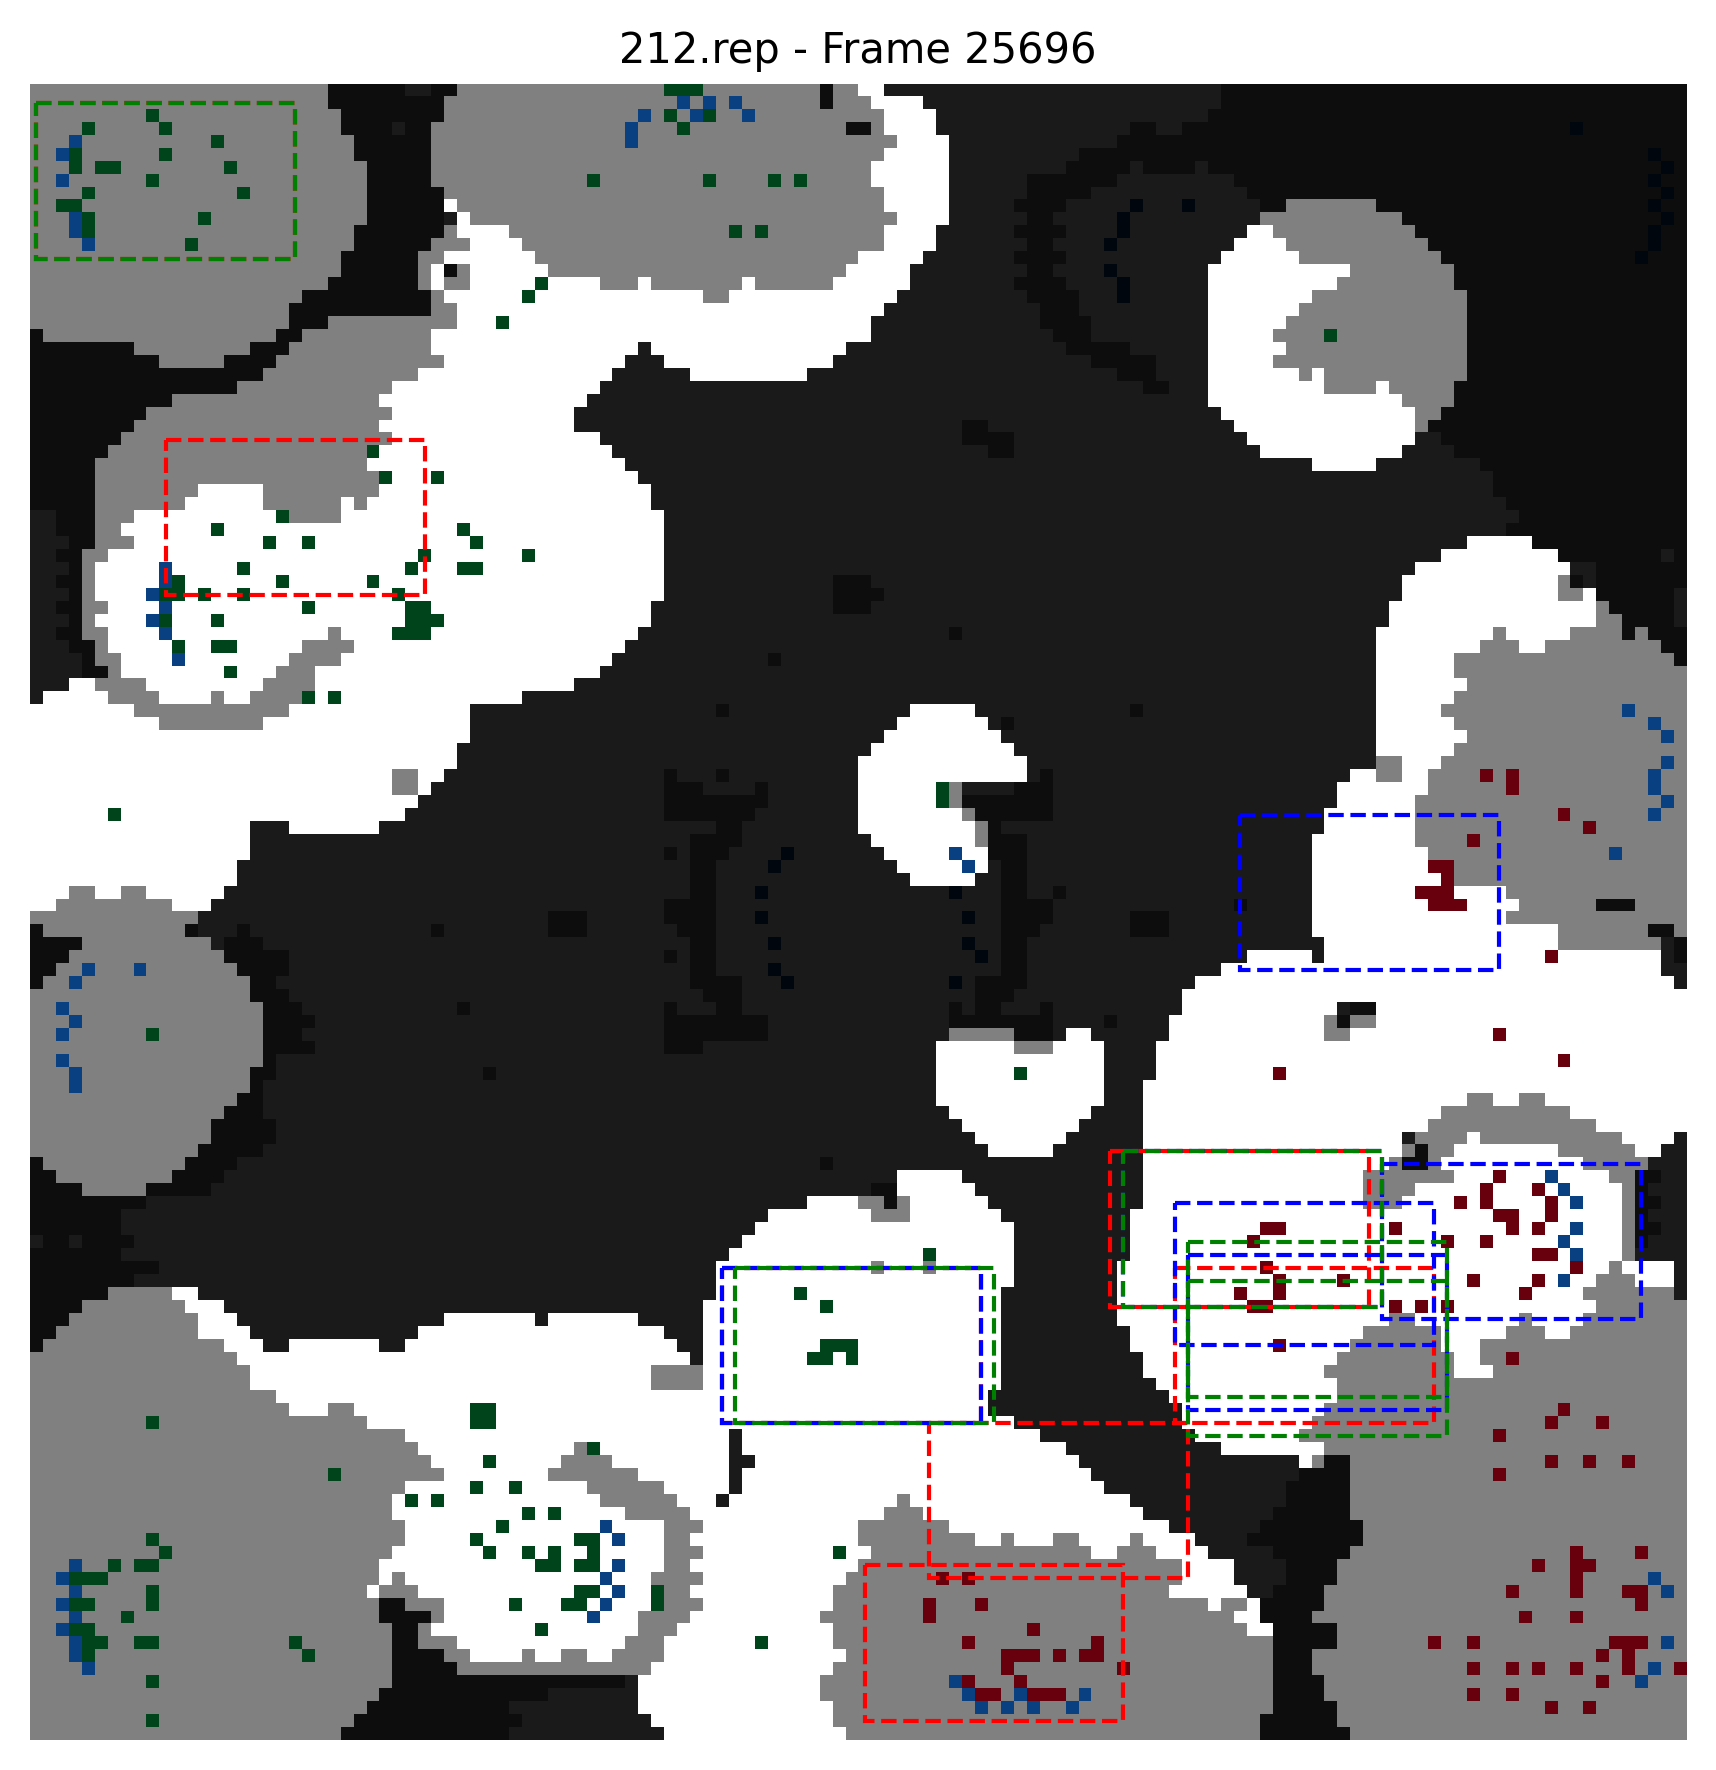

In [64]:
draw_overview(input_numpy,
              rep_name,
              frame_npy.split('.')[0], 
              ground_truths=ground_truths['segmentation'],
              segmentations_list=[prediction_vanilla_results['segmentation'].tolist(), prediction_kbrs_results['segmentation']])